In [ ]:
import pandas as pd
import os
import glob


CARPETA_CARAS = "/Volumes/SSD_VID_PRJ/openface_procesed_csv" 

CARPETA_CUERPOS = "/Volumes/SSD_VID_PRJ/procesados_datos_pose_csv"

CARPETA_SALIDA = "/Volumes/SSD_VID_PRJ/mastered_face_pose"
os.makedirs(CARPETA_SALIDA, exist_ok=True)

archivos_caras = glob.glob(os.path.join(CARPETA_CARAS, "temp_clip_*.csv"))

print(f"Se encontraron {len(archivos_caras)} archivos principales para procesar.")

for ruta_cara in archivos_caras:
    nombre_archivo = os.path.basename(ruta_cara)
    clip_id = nombre_archivo.replace("temp_clip_", "").replace(".csv", "")
    
    print(f"Procesando clip {clip_id}...")
    
    # Leer el CSV principal
    df_principal = pd.read_csv(ruta_cara, skipinitialspace=True)
    archivos_cuerpo = {
        'c': os.path.join(CARPETA_CUERPOS, 'c', f"clip_{clip_id}.csv"),
        'd': os.path.join(CARPETA_CUERPOS, 'd', f"clip_{clip_id}.csv"),
        'i': os.path.join(CARPETA_CUERPOS, 'i', f"clip_{clip_id}.csv")
    }
    
    for camara, ruta_cuerpo in archivos_cuerpo.items():
        if os.path.exists(ruta_cuerpo):
            # Leer CSV del cuerpo
            df_cuerpo = pd.read_csv(ruta_cuerpo)
            
            # Alinear los frames: OpenFace empieza en 1, MediaPipe en 0
            df_cuerpo['frame_match'] = df_cuerpo['Frame'] + 1
            
            # Borrar las columnas que no necesitamos duplicar en el archivo final
            columnas_a_borrar = ['Frame', 'Tiempo_seg']
            df_cuerpo = df_cuerpo.drop(columns=[col for col in columnas_a_borrar if col in df_cuerpo.columns])
            
            # Fusionar (Left Join)
            df_principal = pd.merge(
                df_principal, 
                df_cuerpo, 
                left_on='frame', 
                right_on='frame_match', 
                how='left'
            )
            
            df_principal = df_principal.drop(columns=['frame_match'])
        else:
            print(f"  [Aviso] No se encontró el archivo corporal de la cámara '{camara}' ({ruta_cuerpo})")

    df_principal.insert(0, 'id', clip_id)

    # Guardar el CSV 
    ruta_salida = os.path.join(CARPETA_SALIDA, f"clip_{clip_id}_completo.csv")
    df_principal.to_csv(ruta_salida, index=False)
    print(f"  ✓ Guardado: {ruta_salida}")

print("\n¡Proceso de combinación finalizado!")

Se encontraron 50 archivos principales para procesar.
Procesando clip 1...
  ✓ Guardado: /Volumes/SSD_VID_PRJ/mastered_face_pose/clip_1_completo.csv
Procesando clip 2...
  ✓ Guardado: /Volumes/SSD_VID_PRJ/mastered_face_pose/clip_2_completo.csv
Procesando clip 3...
  ✓ Guardado: /Volumes/SSD_VID_PRJ/mastered_face_pose/clip_3_completo.csv
Procesando clip 4...
  ✓ Guardado: /Volumes/SSD_VID_PRJ/mastered_face_pose/clip_4_completo.csv
Procesando clip 5...
  ✓ Guardado: /Volumes/SSD_VID_PRJ/mastered_face_pose/clip_5_completo.csv
Procesando clip 6...
  ✓ Guardado: /Volumes/SSD_VID_PRJ/mastered_face_pose/clip_6_completo.csv
Procesando clip 7...
  ✓ Guardado: /Volumes/SSD_VID_PRJ/mastered_face_pose/clip_7_completo.csv
Procesando clip 8...
  ✓ Guardado: /Volumes/SSD_VID_PRJ/mastered_face_pose/clip_8_completo.csv
Procesando clip 9...
  ✓ Guardado: /Volumes/SSD_VID_PRJ/mastered_face_pose/clip_9_completo.csv
Procesando clip 10...
  ✓ Guardado: /Volumes/SSD_VID_PRJ/mastered_face_pose/clip_10_complet

Búsqueda de faltantes

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.4)
  from scipy.stats import gaussian_kde


Analizando 50 datasets... Por favor, espera.

 RESUMEN DEL CONJUNTO DE DATOS
 Total de datasets analizados: 50
 Total de frames (filas) globales: 18.298

 TOP 10 VARIABLES CON MÁS DATOS FALTANTES (NaNs)
 1. MunecaDer_Y_i                  |     16.003 nulos |  87.46 %
 2. MunecaDer_X_i                  |     16.003 nulos |  87.46 %
 3. CodoDer_Y_i                    |     15.468 nulos |  84.53 %
 4. CodoDer_X_i                    |     15.468 nulos |  84.53 %
 5. CodoIzq_Y_d                    |     10.388 nulos |  56.77 %
 6. CodoIzq_X_d                    |     10.388 nulos |  56.77 %
 7. MunecaIzq_X_d                  |      9.141 nulos |  49.96 %
 8. MunecaIzq_Y_d                  |      9.141 nulos |  49.96 %
 9. MunecaIzq_X_i                  |      2.376 nulos |  12.99 %
10. MunecaIzq_Y_i                  |      2.376 nulos |  12.99 %


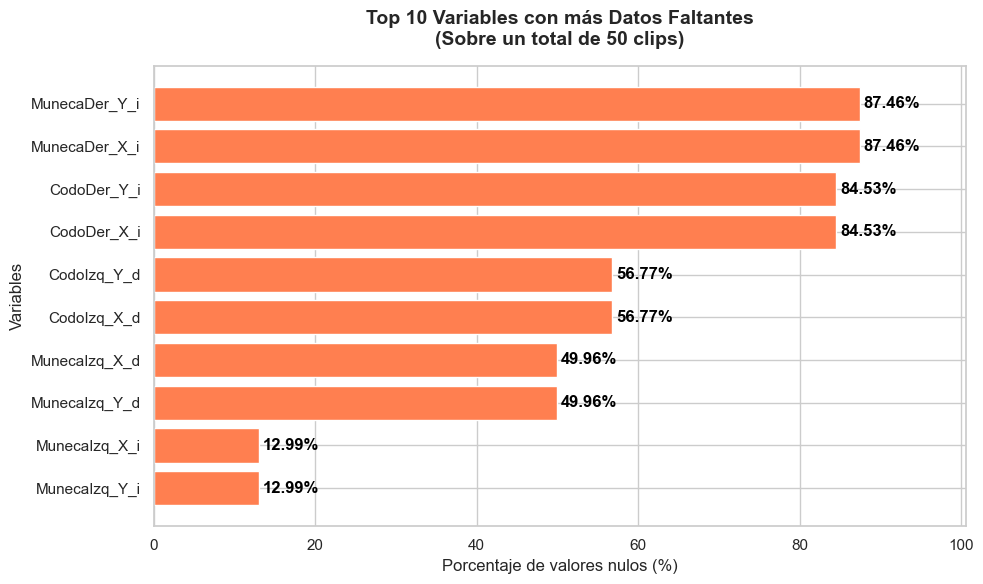

In [ ]:
import pandas as pd
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns

CARPETA_DATOS = "/Volumes/SSD_VID_PRJ/mastered_face_pose"

archivos_csv = glob.glob(os.path.join(CARPETA_DATOS, "*.csv"))

if not archivos_csv:
    print(f"No se encontraron archivos CSV en {CARPETA_DATOS}")
    exit()

print(f"Analizando {len(archivos_csv)} datasets... Por favor, espera.\n")

total_filas = 0
nulos_por_columna = {}
todas_las_columnas = set()

for archivo in archivos_csv:
    df = pd.read_csv(archivo, low_memory=False)
    filas_df = len(df)
    total_filas += filas_df
    
    columnas_df = set(df.columns)
    todas_las_columnas.update(columnas_df)
    
    conteo_nulos = df.isnull().sum()
    for col in columnas_df:
        nulos_por_columna[col] = nulos_por_columna.get(col, 0) + conteo_nulos[col]
    columnas_ausentes = todas_las_columnas - columnas_df
    for col in columnas_ausentes:
        nulos_por_columna[col] = nulos_por_columna.get(col, 0) + filas_df

df_resultados = pd.DataFrame(list(nulos_por_columna.items()), columns=['Variable', 'Faltantes'])
df_resultados['Porcentaje (%)'] = (df_resultados['Faltantes'] / total_filas) * 100
df_resultados = df_resultados.sort_values(by='Faltantes', ascending=False)
top_10 = df_resultados.head(10)


print("="*60)
print(f" RESUMEN DEL CONJUNTO DE DATOS")
print("="*60)
print(f" Total de datasets analizados: {len(archivos_csv)}")
print(f" Total de frames (filas) globales: {total_filas:,}".replace(",", "."))
print("\n" + "="*60)
print(" TOP 10 VARIABLES CON MÁS DATOS FALTANTES (NaNs)")
print("="*60)

for i, row in enumerate(top_10.itertuples(), 1):
    print(f"{i:>2}. {row.Variable:<30} | {int(row.Faltantes):>10,} nulos | {row._3:>6.2f} %".replace(",", "."))

print("="*60)

sns.set_theme(style="whitegrid")

# Crear figura
plt.figure(figsize=(10, 6))
top_10_grafico = top_10.iloc[::-1]
barplot = plt.barh(top_10_grafico['Variable'], top_10_grafico['Porcentaje (%)'], color='coral')
for index, value in enumerate(top_10_grafico['Porcentaje (%)']):
    plt.text(value + 0.5, index, f'{value:.2f}%', va='center', fontweight='bold', color='black')
plt.title(f'Top 10 Variables con más Datos Faltantes\n(Sobre un total de {len(archivos_csv)} clips)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Porcentaje de valores nulos (%)', fontsize=12)
plt.ylabel('Variables', fontsize=12)
plt.xlim(0, max(top_10_grafico['Porcentaje (%)']) * 1.15)
plt.tight_layout()
plt.show()

Se deciden borrar las variables que tienen más de 30% de valores faltantes

In [4]:
import pandas as pd
import os
import glob

CARPETA_DATOS = os.getcwd()

COLUMNAS_A_ELIMINAR = [
    "MunecaDer_Y_i", "MunecaDer_X_i", 
    "CodoDer_X_i", "CodoDer_Y_i", 
    "CodoIzq_Y_d", "CodoIzq_X_d", 
    "MunecaIzq_Y_d", "MunecaIzq_X_d"
]

archivos_csv = glob.glob(os.path.join(CARPETA_DATOS, "*.csv"))

if not archivos_csv:
    print(f"[!] No se encontraron archivos CSV en la ruta: {CARPETA_DATOS}")
    exit()

print(f"Se procesarán {len(archivos_csv)} archivos CSV.\n")

for idx, ruta_archivo in enumerate(archivos_csv, 1):
    nombre_archivo = os.path.basename(ruta_archivo)

    try:
        df = pd.read_csv(ruta_archivo, low_memory=False)

        columnas_presentes = [col for col in COLUMNAS_A_ELIMINAR if col in df.columns]

        if columnas_presentes:
            df.drop(columns=columnas_presentes, inplace=True)

            # 🔥 SOBRESCRIBE EL ARCHIVO ORIGINAL
            df.to_csv(ruta_archivo, index=False)

            print(f"[{idx}/{len(archivos_csv)}] Actualizado: {nombre_archivo}")
        else:
            print(f"[{idx}/{len(archivos_csv)}] Sin cambios: {nombre_archivo}")

    except Exception as e:
        print(f"[ERROR] {nombre_archivo}: {e}")

print("\n✔ PROCESO DE LIMPIEZA COMPLETADO")

Se procesarán 50 archivos CSV.

[1/50] Sin cambios: clip_8_completo.csv
[2/50] Sin cambios: clip_15_completo.csv
[3/50] Sin cambios: clip_40_completo.csv
[4/50] Sin cambios: clip_12_completo.csv
[5/50] Sin cambios: clip_47_completo.csv
[6/50] Sin cambios: clip_24_completo.csv
[7/50] Sin cambios: clip_23_completo.csv
[8/50] Sin cambios: clip_36_completo.csv
[9/50] Sin cambios: clip_31_completo.csv
[10/50] Sin cambios: clip_9_completo.csv
[11/50] Sin cambios: clip_46_completo.csv
[12/50] Sin cambios: clip_13_completo.csv
[13/50] Sin cambios: clip_41_completo.csv
[14/50] Sin cambios: clip_14_completo.csv
[15/50] Sin cambios: clip_30_completo.csv
[16/50] Sin cambios: clip_37_completo.csv
[17/50] Sin cambios: clip_22_completo.csv
[18/50] Sin cambios: clip_25_completo.csv
[19/50] Sin cambios: clip_28_completo.csv
[20/50] Sin cambios: clip_4_completo.csv
[21/50] Sin cambios: clip_3_completo.csv
[22/50] Sin cambios: clip_19_completo.csv
[23/50] Sin cambios: clip_29_completo.csv
[24/50] Sin cam

Imputación de valores faltantes

In [ ]:
import pandas as pd
import glob
import os

input_folder = os.getcwd()

csv_files = glob.glob(os.path.join(input_folder, '*.csv'))
print(f"Se encontraron {len(csv_files)} archivos para procesar y sobrescribir.\n")

cols_to_ignore = ['id', 'frame', 'face_id', 'timestamp', 'success', 'confidence']
total_nulos_antes = 0
total_nulos_despues = 0

for file in csv_files:
    filename = os.path.basename(file)
    df = pd.read_csv(file)
    nulos_antes = df.isnull().sum().sum()
    total_nulos_antes += nulos_antes
    feature_cols = [col for col in df.columns if col not in cols_to_ignore]
    df[feature_cols] = df[feature_cols].interpolate(method='linear', limit_direction='both')
    
    # Rellenar posibles NaNs en los bordes (inicio o fin del clip)
    df[feature_cols] = df[feature_cols].ffill().bfill()
    
    # Recuento de nulos DESPUÉS de imputar
    nulos_despues = df.isnull().sum().sum()
    total_nulos_despues += nulos_despues

    print(f"Sobrescribiendo: {filename} | Nulos antes: {nulos_antes} -> Nulos después: {nulos_despues}")
    df.to_csv(file, index=False)
print("\n" + "="*50)
print("REPORTE FINAL DE IMPUTACIÓN Y SOBRESCRITURA")
print("="*50)
print(f"Total de archivos procesados: {len(csv_files)}")
print(f"Total de valores nulos encontrados originalmente: {total_nulos_antes}")
print(f"Total de valores nulos tras la imputación: {total_nulos_despues}")
if total_nulos_despues == 0:
    print("¡Éxito! Todos los datos faltantes han sido imputados y los archivos originales actualizados.")
else:
    print("ATENCIÓN: Aún quedan valores nulos. Revisa si hay columnas completamente vacías.")
print("="*50)

Se encontraron 50 archivos para procesar y sobrescribir.

Sobrescribiendo: clip_8_completo.csv | Nulos antes: 372 -> Nulos después: 0
Sobrescribiendo: clip_15_completo.csv | Nulos antes: 28 -> Nulos después: 0
Sobrescribiendo: clip_40_completo.csv | Nulos antes: 34 -> Nulos después: 0
Sobrescribiendo: clip_12_completo.csv | Nulos antes: 124 -> Nulos después: 0
Sobrescribiendo: clip_47_completo.csv | Nulos antes: 44 -> Nulos después: 0
Sobrescribiendo: clip_24_completo.csv | Nulos antes: 10 -> Nulos después: 0
Sobrescribiendo: clip_23_completo.csv | Nulos antes: 10 -> Nulos después: 0
Sobrescribiendo: clip_36_completo.csv | Nulos antes: 28 -> Nulos después: 0
Sobrescribiendo: clip_31_completo.csv | Nulos antes: 18 -> Nulos después: 0
Sobrescribiendo: clip_9_completo.csv | Nulos antes: 92 -> Nulos después: 0
Sobrescribiendo: clip_46_completo.csv | Nulos antes: 938 -> Nulos después: 0
Sobrescribiendo: clip_13_completo.csv | Nulos antes: 570 -> Nulos después: 0
Sobrescribiendo: clip_41_com